# Utah Legislature Bill Outcome Analysis — Primary Subjects
### DS 2500 Final Project — Analysis Methods

This notebook implements the analysis pipeline using **primary subject classification** — each bill is assigned to exactly one subject area rather than all applicable subject tags. This simplifies the subject variable to a true categorical and may yield cleaner patterns.

**Research Questions:**
1. Which aspects of a bill have the most influence over its outcome?
2. Can the outcome of a bill be predicted by analyzing its characteristics?
3. Do economic indicators influence bill outcomes, and does including them improve predictability?

## 0. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

In [2]:
# Load primary subject dataset
df_primary = pd.read_csv('df_primary.csv')
print(f"Primary subject dataset: {df_primary.shape[0]} bills")

# Merge party from the multi-subject dataset (party wasn't included in df_primary)
df_bills = pd.read_csv('df_bills.csv')[['bill_id', 'session_year', 'party', 'party1']]
df_raw = df_primary.merge(df_bills, on=['bill_id', 'session_year'], how='left')
print(f"After merging party info: {df_raw.shape[0]} bills")
print(f"Bills with missing party after merge: {df_raw['party'].isnull().sum()}")

# Filter to only bills that had a floor sponsor
# A floor sponsor is a procedural prerequisite for passage — bills without one
# never had a real chance of passing, so including them would let the model
# "cheat" by just learning that gatekeeper step instead of substantive patterns.
df = df_raw[df_raw['floorspon1'] == 1].copy()
print(f"\nAfter filtering to floor-sponsored bills: {df.shape[0]} bills ({df.shape[0]/df_raw.shape[0]:.1%} of total)")
print(f"\nOutcome distribution (passed):")
print(df['passed'].value_counts().to_string())
print(f"\nPass rate in analysis sample: {df['passed'].mean():.1%}")
print(f"\nSponsor party distribution:")
print(df['party'].value_counts().to_string())

Primary subject dataset: 8705 bills
After merging party info: 8705 bills
Bills with missing party after merge: 0

After filtering to floor-sponsored bills: 6730 bills (77.3% of total)

Outcome distribution (passed):
passed
1    5347
0    1383

Pass rate in analysis sample: 79.5%

Sponsor party distribution:
party
Rep    5789
Dem     866
FWD      75


## 1. Exploratory Data Analysis

### 1.1 Define Variable Groups

Key change from the multi-subject analysis: each bill now has exactly one primary subject, so `subject_group` is a clean categorical variable. We still have the 22 binary dummies for use in linear models, but tree models can use `subject_group` directly.

- `money1` = binary flag for whether the bill had money appropriated
- `money_sum_real` = inflation-adjusted total appropriation amount
- `num_sub_new` = derived substitute count from enrolled version
- `committee1` = binary flag for coming out of committee
- `party1` = binary flag for Republican sponsor (1 = Rep, 0 = Dem/FWD)
- `subject_group` = categorical (22 levels + "other" for the 33 unclassified bills)
- `passed` = binary outcome; `location_stage` = ordinal outcome (0–3)

In [3]:
# Subject area dummies (22 groups — now primary only)
SUBJECT_COLS = [
    'agri_food', 'arts_cult_rec', 'bus_comm', 'civ_rights_libs', 'crim_justice',
    'econ_dev', 'ed_k12', 'elect_gov', 'energy', 'env_nr', 'fam_ss',
    'health_care', 'higher_ed', 'house_land_use', 'labor_ee', 'local_gov',
    'no_subject', 'pub_safe_emerg', 'retire_ben', 'tax_fin', 'tech_data', 'transpo'
]

# Bill-level covariates
BILL_COVARIATES = ['committee1', 'money1', 'num_sub_new', 'money_sum_real', 'party1']

# ACS economic indicators (missing for 2024-2026)
ECON_VARS = ['real_gdp', 'rental_vacancy_rate', 'poverty_rate', 'inflation']

# Originating chamber — binary encode
df['house_origin'] = (df['originating_chamber'] == 'House').astype(int)

# Subjects changed — binary encode
df['subjects_changed_bin'] = df['subjects_changed'].astype(int)

# Drop any rows where party1 didn't merge (shouldn't be many)
df = df.dropna(subset=['party1']).copy()
df['party1'] = df['party1'].astype(int)

print("Variable groups defined.")
print(f"Analysis sample: {len(df)} bills")
print(f"  Subject dummies (primary): {len(SUBJECT_COLS)}")
print(f"  Bill covariates: {BILL_COVARIATES}")
print(f"  ACS economic vars: {ECON_VARS}")

Variable groups defined.
Analysis sample: 6730 bills
  Subject dummies (primary): 22
  Bill covariates: ['committee1', 'money1', 'num_sub_new', 'money_sum_real', 'party1']
  ACS economic vars: ['real_gdp', 'rental_vacancy_rate', 'poverty_rate', 'inflation']


### 1.2 Pass Rates by Primary Subject

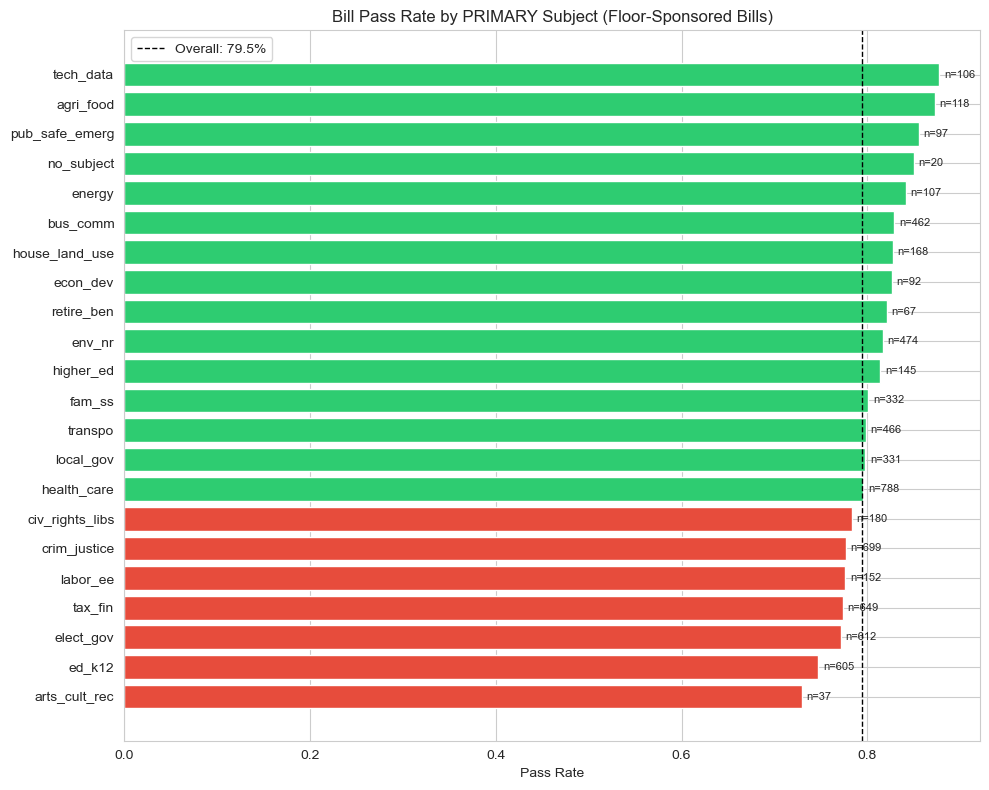

In [5]:
pass_rates = {}
for col in SUBJECT_COLS:
    subset = df[df[col] == 1]
    if len(subset) > 0:
        pass_rates[col] = {'pass_rate': subset['passed'].mean(), 'count': len(subset)}

pr_df = pd.DataFrame(pass_rates).T.sort_values('pass_rate', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#2ecc71' if r > df['passed'].mean() else '#e74c3c' for r in pr_df['pass_rate']]
bars = ax.barh(pr_df.index, pr_df['pass_rate'], color=colors, edgecolor='white')
ax.axvline(df['passed'].mean(), color='black', linestyle='--', linewidth=1, label=f'Overall: {df["passed"].mean():.1%}')
ax.set_xlabel('Pass Rate')
ax.set_title('Bill Pass Rate by PRIMARY Subject (Floor-Sponsored Bills)')
ax.legend()

for bar, (_, row) in zip(bars, pr_df.iterrows()):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'n={int(row["count"])}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

### 1.3 Pass Rates by Bill Characteristics & Sponsor Party

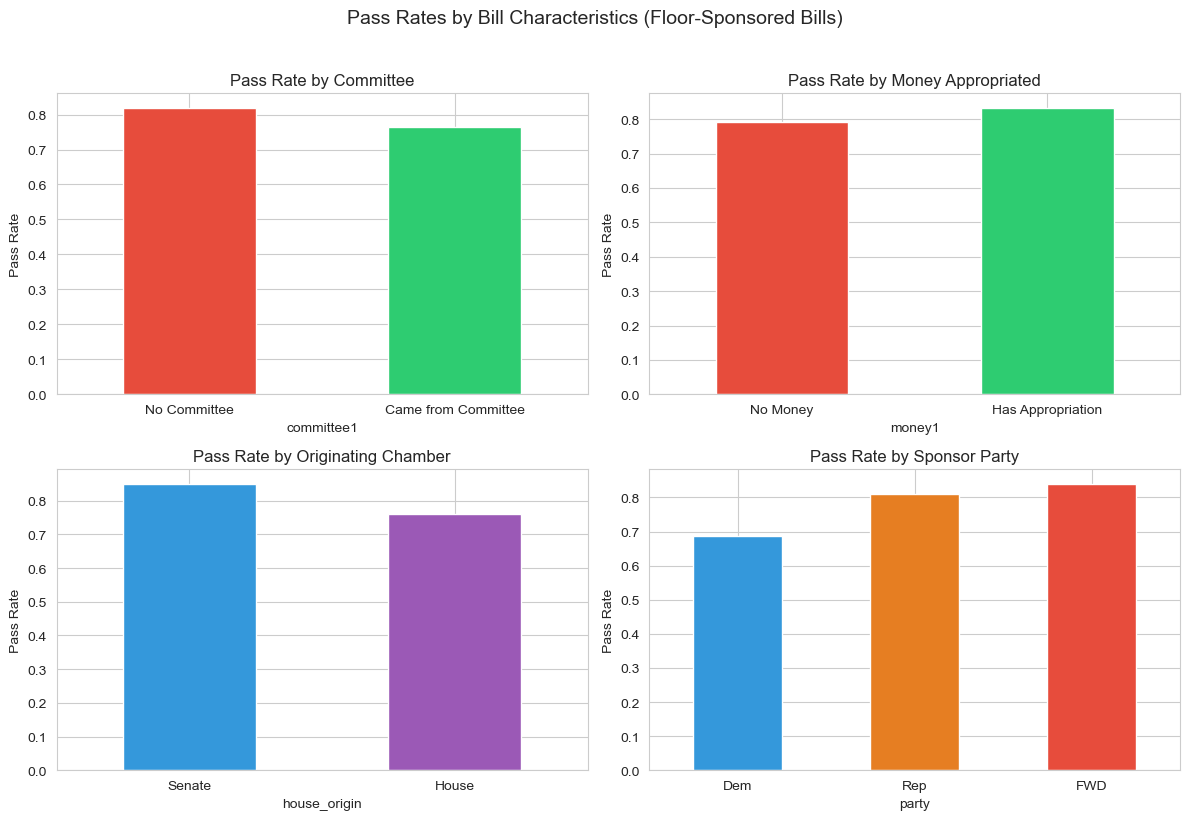

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

ax = axes[0, 0]
df.groupby('committee1')['passed'].mean().plot(kind='bar', ax=ax, color=['#e74c3c', '#2ecc71'])
ax.set_title('Pass Rate by Committee')
ax.set_xticklabels(['No Committee', 'Came from Committee'], rotation=0)
ax.set_ylabel('Pass Rate')

ax = axes[0, 1]
df.groupby('money1')['passed'].mean().plot(kind='bar', ax=ax, color=['#e74c3c', '#2ecc71'])
ax.set_title('Pass Rate by Money Appropriated')
ax.set_xticklabels(['No Money', 'Has Appropriation'], rotation=0)
ax.set_ylabel('Pass Rate')

ax = axes[1, 0]
df.groupby('house_origin')['passed'].mean().plot(kind='bar', ax=ax, color=['#3498db', '#9b59b6'])
ax.set_title('Pass Rate by Originating Chamber')
ax.set_xticklabels(['Senate', 'House'], rotation=0)
ax.set_ylabel('Pass Rate')

ax = axes[1, 1]
party_pass = df.groupby('party')['passed'].mean().sort_values()
party_pass.plot(kind='bar', ax=ax, color=['#3498db', '#e67e22', '#e74c3c'])
ax.set_title('Pass Rate by Sponsor Party')
ax.set_ylabel('Pass Rate')
ax.set_xticklabels(party_pass.index, rotation=0)

plt.suptitle('Pass Rates by Bill Characteristics (Floor-Sponsored Bills)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 1.4 Primary Subject × Party Pass Rate

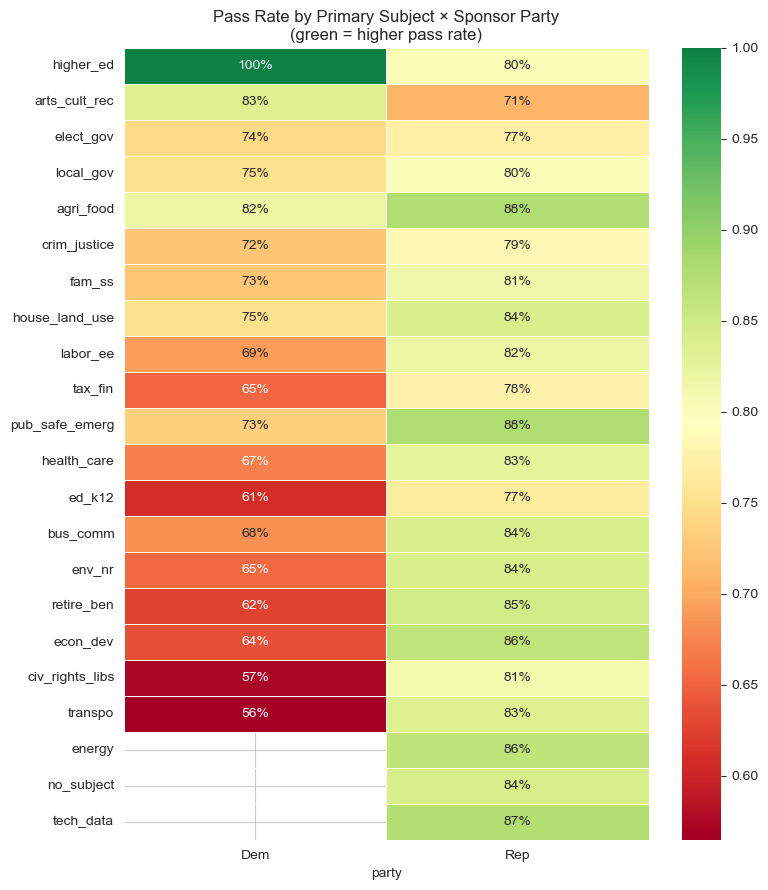

Largest Republican advantage (Rep - Dem pass rate):
subject
transpo            0.269642
civ_rights_libs    0.238698
econ_dev           0.224396
retire_ben         0.222458
env_nr             0.184634

Largest Democrat advantage:
subject
higher_ed       -0.198529
arts_cult_rec   -0.123656
elect_gov        0.026688
local_gov        0.049331
agri_food        0.059177


In [7]:
subject_party = []
for col in SUBJECT_COLS:
    for party in ['Rep', 'Dem']:
        subset = df[(df[col] == 1) & (df['party'] == party)]
        if len(subset) > 5:
            subject_party.append({'subject': col, 'party': party,
                                  'pass_rate': subset['passed'].mean(), 'n': len(subset)})

sp_df = pd.DataFrame(subject_party)
sp_pivot = sp_df.pivot(index='subject', columns='party', values='pass_rate')
sp_pivot['gap'] = sp_pivot['Rep'] - sp_pivot['Dem']
sp_pivot = sp_pivot.sort_values('gap')

fig, ax = plt.subplots(figsize=(8, 9))
sns.heatmap(sp_pivot[['Dem', 'Rep']], annot=True, fmt='.0%', cmap='RdYlGn',
            center=df['passed'].mean(), linewidths=0.5, ax=ax)
ax.set_title('Pass Rate by Primary Subject × Sponsor Party\n(green = higher pass rate)')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

print("Largest Republican advantage (Rep - Dem pass rate):")
print(sp_pivot['gap'].sort_values(ascending=False).head(5).to_string())
print("\nLargest Democrat advantage:")
print(sp_pivot['gap'].sort_values().head(5).to_string())

### 1.5 Pass Rates Over Time & Economic Indicators

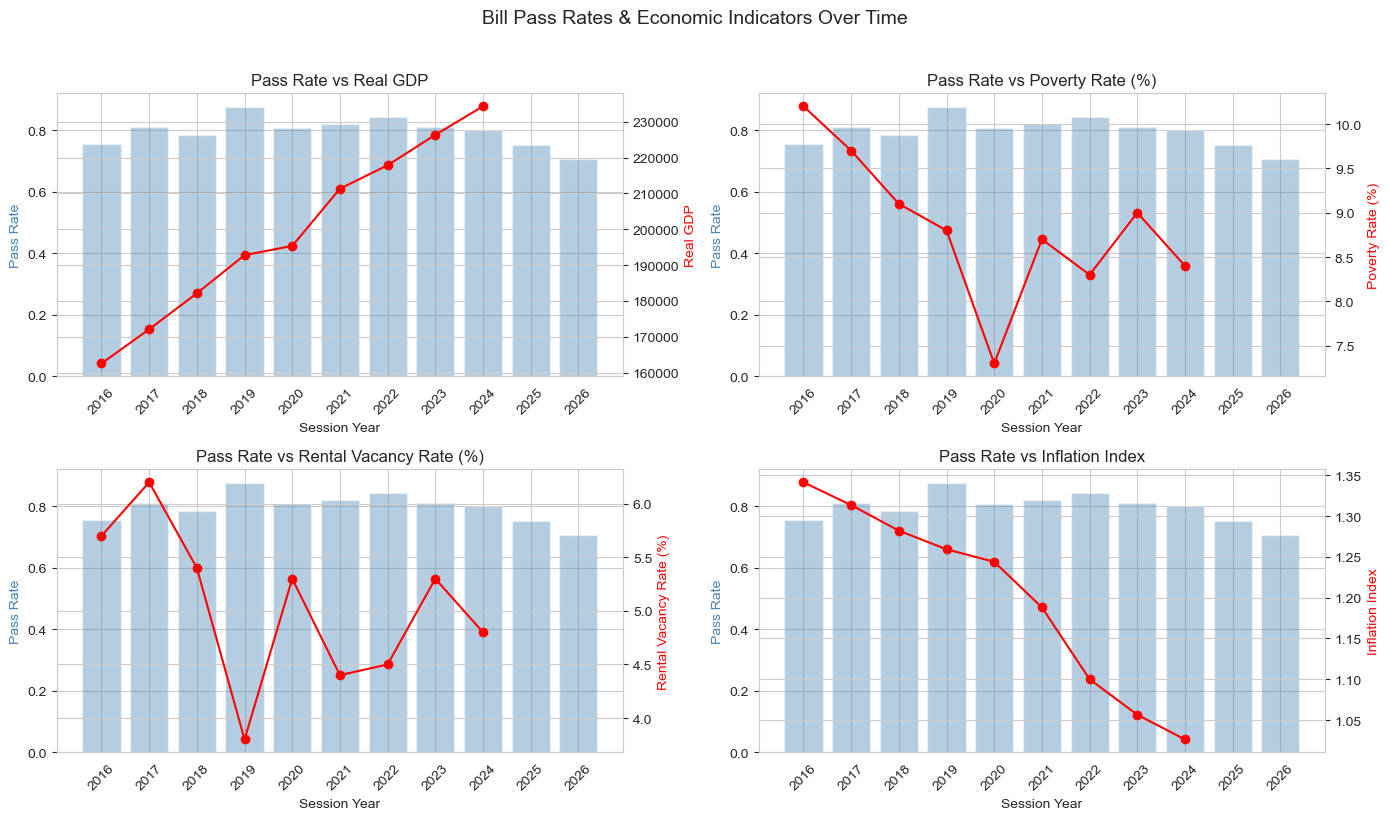

In [8]:
yearly = df.groupby('session_year').agg(
    pass_rate=('passed', 'mean'),
    n_bills=('passed', 'count'),
    real_gdp=('real_gdp', 'first'),
    poverty_rate=('poverty_rate', 'first'),
    rental_vacancy_rate=('rental_vacancy_rate', 'first'),
    inflation=('inflation', 'first')
).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, econ_var, label in zip(axes.flatten(),
    ['real_gdp', 'poverty_rate', 'rental_vacancy_rate', 'inflation'],
    ['Real GDP', 'Poverty Rate (%)', 'Rental Vacancy Rate (%)', 'Inflation Index']):

    ax2 = ax.twinx()
    ax.bar(yearly['session_year'], yearly['pass_rate'], alpha=0.4, color='steelblue', label='Pass Rate')
    ax2.plot(yearly['session_year'], yearly[econ_var], 'ro-', label=label)
    ax.set_xlabel('Session Year')
    ax.set_ylabel('Pass Rate', color='steelblue')
    ax2.set_ylabel(label, color='red')
    ax.set_title(f'Pass Rate vs {label}')
    ax.set_xticks(yearly['session_year'])
    ax.set_xticklabels(yearly['session_year'], rotation=45)

plt.suptitle('Bill Pass Rates & Economic Indicators Over Time', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 1.6 Correlation Matrix — Numeric Covariates

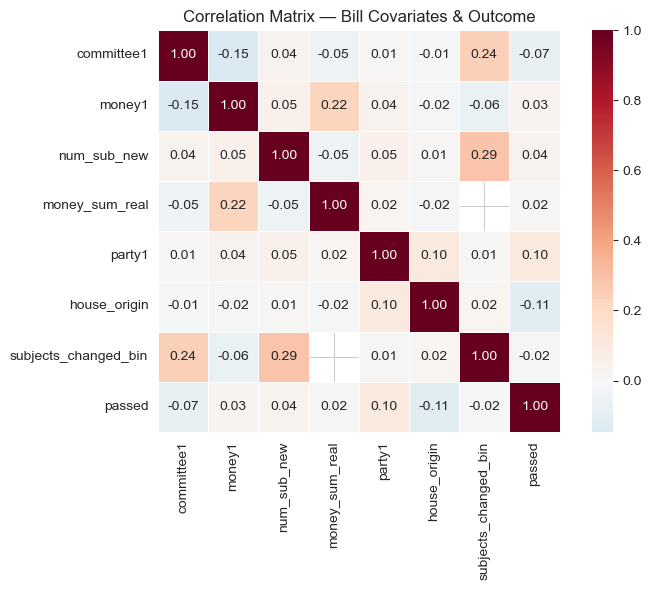

In [9]:
corr_cols = BILL_COVARIATES + ['house_origin', 'subjects_changed_bin', 'passed']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix — Bill Covariates & Outcome')
plt.tight_layout()
plt.show()

## 2. Predictive Modeling — Logistic Regression

Three logistic regression models, built incrementally:

1. **Model 1 — Bill characteristics only**: primary subject dummies + bill covariates (chamber, committee, substitutes, money, sponsor party)
2. **Model 2 — Bill + ACS economic indicators**: adds real GDP, poverty rate, rental vacancy rate, inflation
3. **Model 3 — Bill + ACS + interactions**: adds subject × economic and party × economic interaction terms

5-fold stratified CV; compare accuracy, F1, and ROC-AUC.

**Note:** ACS data is missing for 2024–2026, so Models 2 and 3 are restricted to 2016–2023 sessions. Model 1 is fit on the same subset for fair comparison.

In [10]:
# ── Prepare feature matrices ──
X_full_cols = SUBJECT_COLS + BILL_COVARIATES + ['house_origin', 'subjects_changed_bin']
y_full = df['passed'].copy()

df_econ = df.dropna(subset=ECON_VARS).copy()
print(f"Analysis sample (floor-sponsored): {len(df)} bills")
print(f"With ACS data (2016-2023): {len(df_econ)} bills")
print(f"Pass rate in ACS subset: {df_econ['passed'].mean():.1%}")

y_econ = df_econ['passed'].copy()

X1 = df_econ[X_full_cols].copy()
X2_cols = X_full_cols + ECON_VARS
X2 = df_econ[X2_cols].copy()

# Model 3 interactions
interaction_subjects = ['health_care', 'fam_ss', 'ed_k12', 'crim_justice', 'tax_fin']
X3 = X2.copy()
for econ in ECON_VARS:
    for subj in interaction_subjects:
        X3[f'{econ}_x_{subj}'] = X3[econ] * X3[subj]
for econ in ECON_VARS:
    X3[f'{econ}_x_party1'] = X3[econ] * X3['party1']

print(f"\nFeature counts: Model 1={X1.shape[1]}, Model 2={X2.shape[1]}, Model 3={X3.shape[1]}")

Analysis sample (floor-sponsored): 6730 bills
With ACS data (2016-2023): 5312 bills
Pass rate in ACS subset: 81.2%

Feature counts: Model 1=29, Model 2=33, Model 3=57


In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scaler = StandardScaler()

results = {}
models_dict = {'Model 1: Bill Only': X1, 'Model 2: Bill + ACS': X2, 'Model 3: Bill + ACS + Interactions': X3}

for name, X in models_dict.items():
    X_scaled = scaler.fit_transform(X)
    lr = LogisticRegression(max_iter=1000, random_state=42)

    acc = cross_val_score(lr, X_scaled, y_econ, cv=cv, scoring='accuracy')
    f1 = cross_val_score(lr, X_scaled, y_econ, cv=cv, scoring='f1')
    auc = cross_val_score(lr, X_scaled, y_econ, cv=cv, scoring='roc_auc')

    results[name] = {
        'Accuracy': f'{acc.mean():.3f} ± {acc.std():.3f}',
        'F1 Score': f'{f1.mean():.3f} ± {f1.std():.3f}',
        'ROC-AUC': f'{auc.mean():.3f} ± {auc.std():.3f}',
        'acc_mean': acc.mean(), 'f1_mean': f1.mean(), 'auc_mean': auc.mean()
    }

results_df = pd.DataFrame(results).T[['Accuracy', 'F1 Score', 'ROC-AUC']]
print("5-Fold Stratified Cross-Validation Results (Primary Subjects)")
print("=" * 60)
print(results_df.to_string())

5-Fold Stratified Cross-Validation Results (Primary Subjects)
                                         Accuracy       F1 Score        ROC-AUC
Model 1: Bill Only                  0.812 ± 0.000  0.896 ± 0.000  0.611 ± 0.036
Model 2: Bill + ACS                 0.812 ± 0.000  0.896 ± 0.000  0.613 ± 0.037
Model 3: Bill + ACS + Interactions  0.812 ± 0.000  0.896 ± 0.000  0.619 ± 0.029


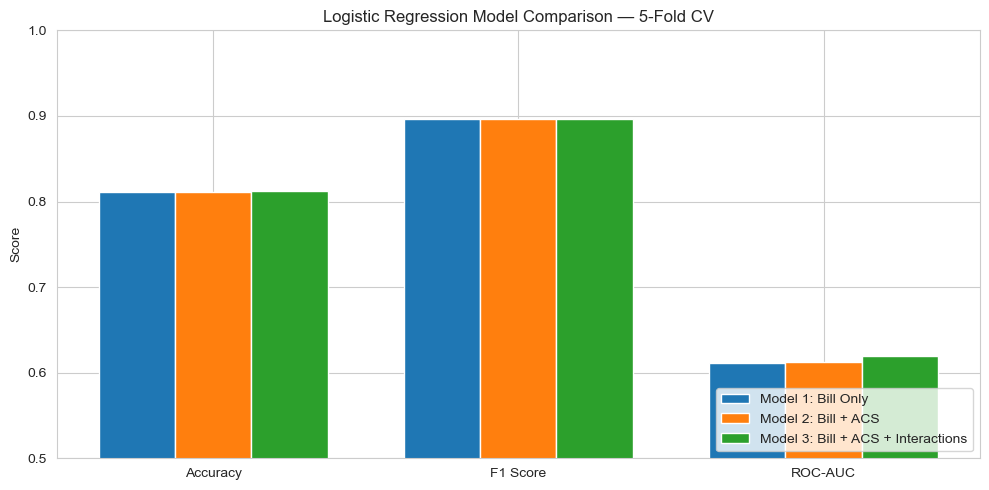

In [12]:
metrics = ['acc_mean', 'f1_mean', 'auc_mean']
labels = ['Accuracy', 'F1 Score', 'ROC-AUC']
model_names = list(results.keys())

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(labels))
width = 0.25

for i, name in enumerate(model_names):
    vals = [results[name][m] for m in metrics]
    ax.bar(x + i * width, vals, width, label=name)

ax.set_ylabel('Score')
ax.set_title('Logistic Regression Model Comparison — 5-Fold CV')
ax.set_xticks(x + width)
ax.set_xticklabels(labels)
ax.legend(loc='lower right')
ax.set_ylim(0.5, 1.0)
plt.tight_layout()
plt.show()

### 2.1 Logistic Regression Coefficients (Best Model)

Best model by AUC: Model 3: Bill + ACS + Interactions


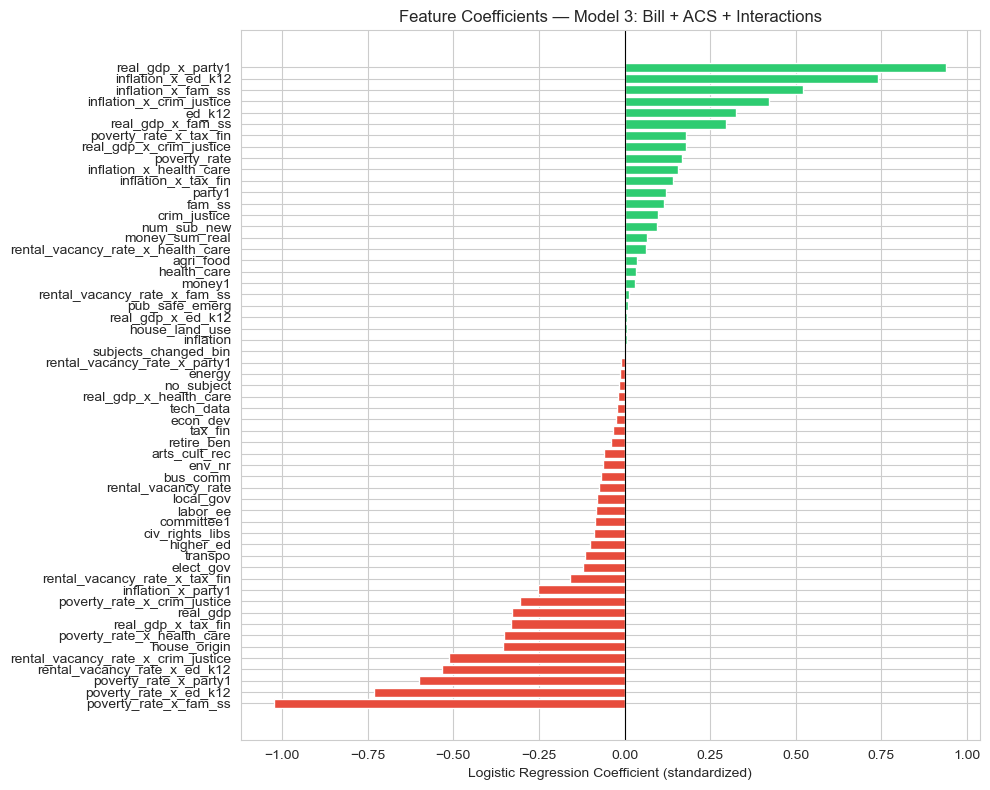


Top 10 positive predictors of passage:
                 Feature  Coefficient  Odds Ratio
 inflation_x_health_care     0.154684    1.167289
            poverty_rate     0.168481    1.183506
 real_gdp_x_crim_justice     0.179562    1.196694
  poverty_rate_x_tax_fin     0.179809    1.196989
       real_gdp_x_fam_ss     0.295059    1.343205
                  ed_k12     0.325271    1.384406
inflation_x_crim_justice     0.422027    1.525050
      inflation_x_fam_ss     0.521741    1.684958
      inflation_x_ed_k12     0.740246    2.096451
       real_gdp_x_party1     0.939163    2.557840

Top 10 negative predictors of passage:
                           Feature  Coefficient  Odds Ratio
             poverty_rate_x_fam_ss    -1.022003    0.359873
             poverty_rate_x_ed_k12    -0.730174    0.481825
             poverty_rate_x_party1    -0.601365    0.548063
      rental_vacancy_rate_x_ed_k12    -0.531461    0.587746
rental_vacancy_rate_x_crim_justice    -0.513049    0.598667
          

In [13]:
best_name = max(results, key=lambda k: results[k]['auc_mean'])
best_X = models_dict[best_name]
print(f"Best model by AUC: {best_name}")

X_scaled = scaler.fit_transform(best_X)
lr_best = LogisticRegression(max_iter=1000, random_state=42)
lr_best.fit(X_scaled, y_econ)

coef_df = pd.DataFrame({
    'Feature': best_X.columns,
    'Coefficient': lr_best.coef_[0],
    'Odds Ratio': np.exp(lr_best.coef_[0])
}).sort_values('Coefficient', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#2ecc71' if c > 0 else '#e74c3c' for c in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Logistic Regression Coefficient (standardized)')
ax.set_title(f'Feature Coefficients — {best_name}')
plt.tight_layout()
plt.show()

print("\nTop 10 positive predictors of passage:")
print(coef_df.tail(10)[['Feature', 'Coefficient', 'Odds Ratio']].to_string(index=False))
print("\nTop 10 negative predictors of passage:")
print(coef_df.head(10)[['Feature', 'Coefficient', 'Odds Ratio']].to_string(index=False))

### 2.2 ROC Curve

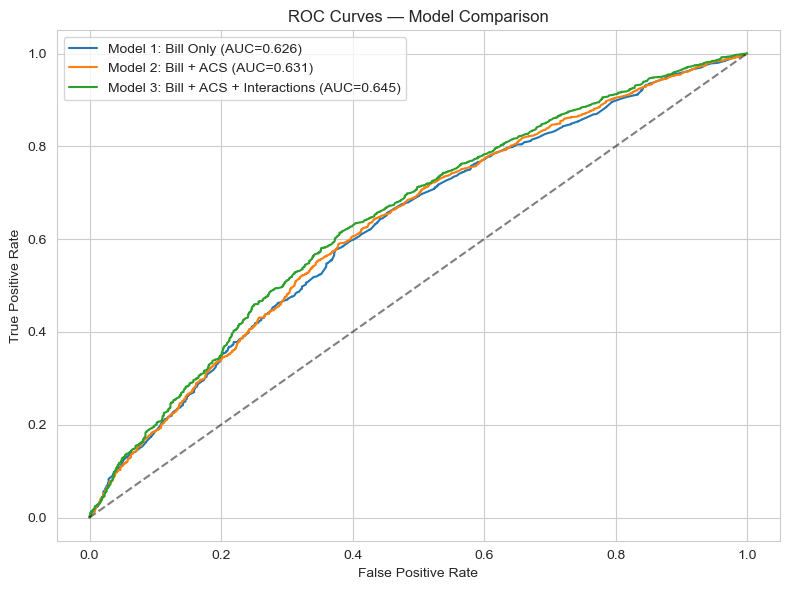

In [14]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, X in models_dict.items():
    X_scaled = scaler.fit_transform(X)
    lr = LogisticRegression(max_iter=1000, random_state=42)
    lr.fit(X_scaled, y_econ)
    y_prob = lr.predict_proba(X_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_econ, y_prob)
    auc_val = roc_auc_score(y_econ, y_prob)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc_val:.3f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Model Comparison')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Classification Trees & Random Forest

Decision trees serve as the interpretable, constituent-facing output. We fit:
1. A single decision tree (pruned for readability) to visualize the decision rules
2. A random forest to get stable feature importance rankings

Both use the full floor-sponsored sample (all years, no ACS restriction) and include `party1`. Since each bill now has a single primary subject, the tree splits on subject dummies should be cleaner and more interpretable.

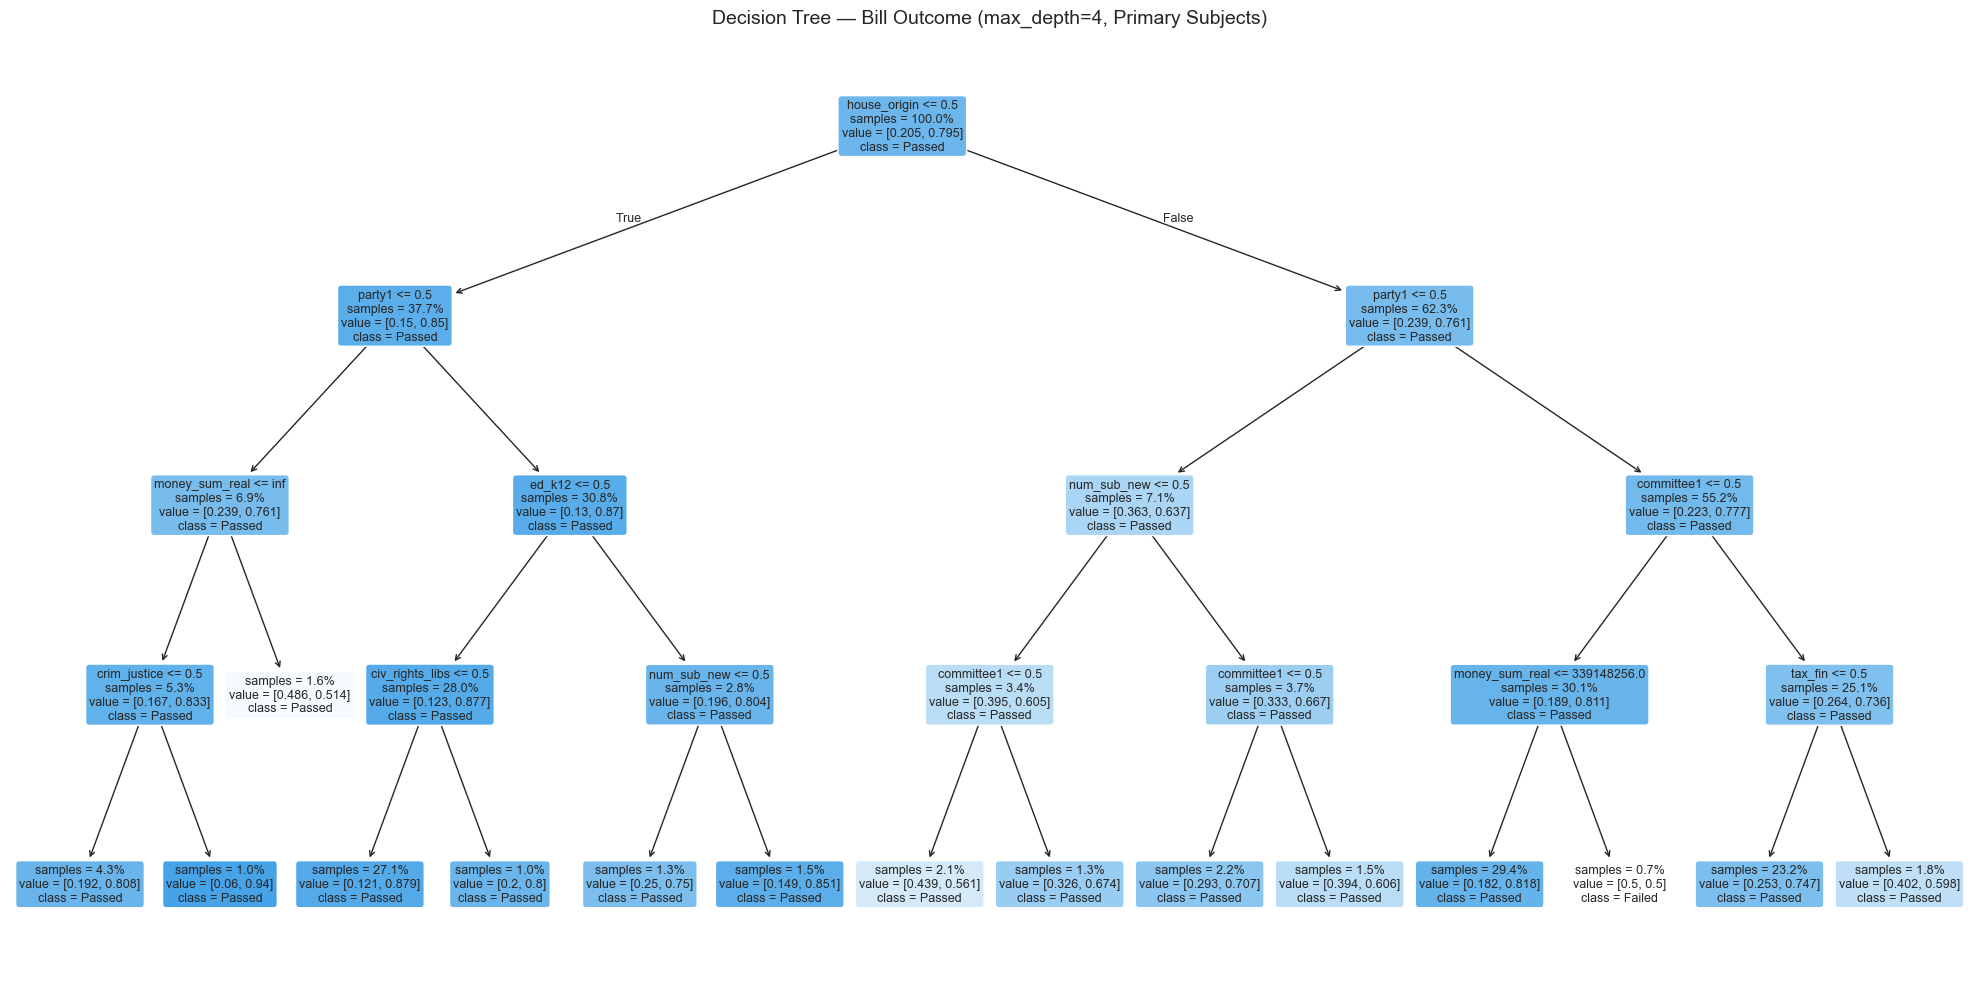

Decision Tree CV Accuracy: 0.682 ± 0.225


In [15]:
feature_cols = SUBJECT_COLS + BILL_COVARIATES + ['house_origin', 'subjects_changed_bin']

dt = DecisionTreeClassifier(max_depth=4, min_samples_leaf=50, random_state=42)
dt.fit(df[feature_cols], y_full)

fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(dt, feature_names=feature_cols, class_names=['Failed', 'Passed'],
          filled=True, rounded=True, fontsize=9, ax=ax,
          proportion=True, impurity=False)
ax.set_title('Decision Tree — Bill Outcome (max_depth=4, Primary Subjects)', fontsize=14)
plt.tight_layout()
plt.show()

dt_cv = cross_val_score(dt, df[feature_cols], y_full, cv=5, scoring='accuracy')
print(f"Decision Tree CV Accuracy: {dt_cv.mean():.3f} ± {dt_cv.std():.3f}")

### 3.1 Random Forest — Feature Importance

Random Forest 5-Fold CV:
  Accuracy: 0.725 ± 0.140
  F1 Score: 0.817 ± 0.137
  ROC-AUC:  0.566 ± 0.064


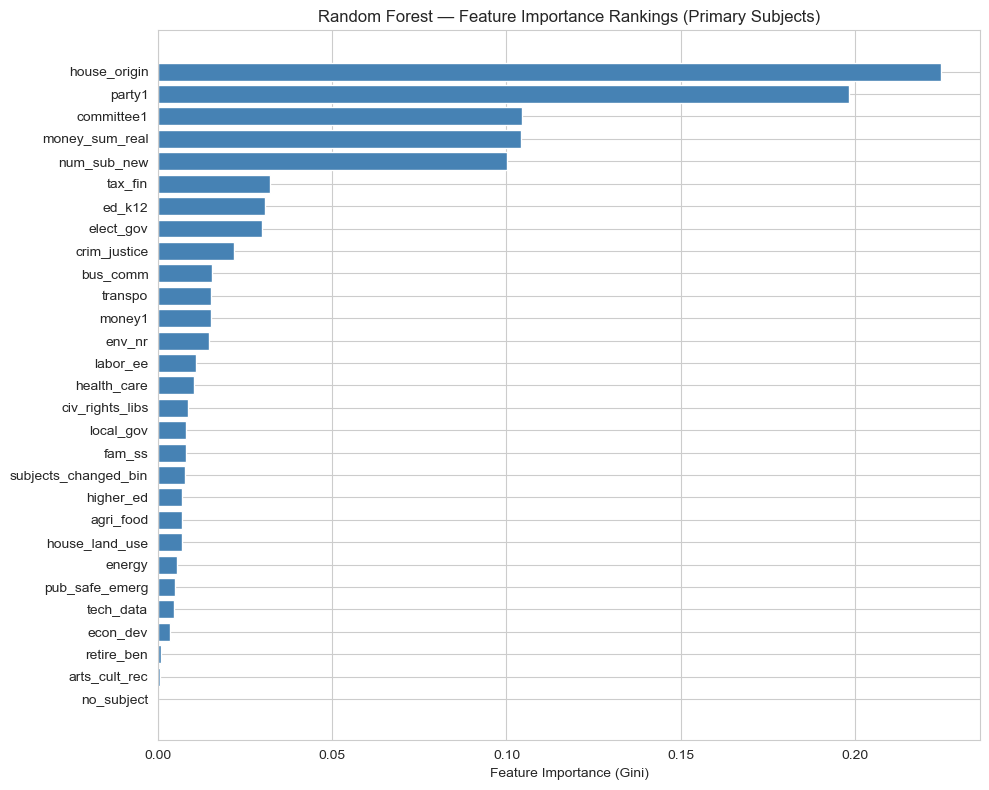


Top 10 most important features:
       Feature  Importance
      bus_comm    0.015343
  crim_justice    0.021732
     elect_gov    0.029701
        ed_k12    0.030761
       tax_fin    0.032001
   num_sub_new    0.100119
money_sum_real    0.104130
    committee1    0.104452
        party1    0.198426
  house_origin    0.224684


In [16]:
rf = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=20,
                            random_state=42, n_jobs=-1)
rf.fit(df[feature_cols], y_full)

rf_cv_acc = cross_val_score(rf, df[feature_cols], y_full, cv=5, scoring='accuracy')
rf_cv_f1 = cross_val_score(rf, df[feature_cols], y_full, cv=5, scoring='f1')
rf_cv_auc = cross_val_score(rf, df[feature_cols], y_full, cv=5, scoring='roc_auc')
print(f"Random Forest 5-Fold CV:")
print(f"  Accuracy: {rf_cv_acc.mean():.3f} ± {rf_cv_acc.std():.3f}")
print(f"  F1 Score: {rf_cv_f1.mean():.3f} ± {rf_cv_f1.std():.3f}")
print(f"  ROC-AUC:  {rf_cv_auc.mean():.3f} ± {rf_cv_auc.std():.3f}")

imp_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(imp_df['Feature'], imp_df['Importance'], color='steelblue', edgecolor='white')
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('Random Forest — Feature Importance Rankings (Primary Subjects)')
plt.tight_layout()
plt.show()

print("\nTop 10 most important features:")
print(imp_df.tail(10)[['Feature', 'Importance']].to_string(index=False))

### 3.2 Random Forest — Confusion Matrix

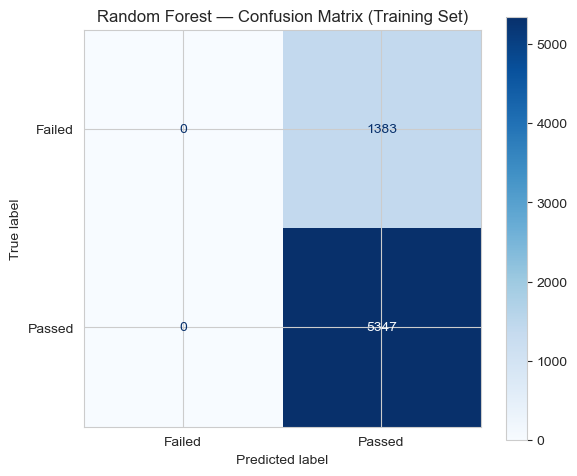

              precision    recall  f1-score   support

      Failed       0.00      0.00      0.00      1383
      Passed       0.79      1.00      0.89      5347

    accuracy                           0.79      6730
   macro avg       0.40      0.50      0.44      6730
weighted avg       0.63      0.79      0.70      6730



In [17]:
y_pred_rf = rf.predict(df[feature_cols])

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_full, y_pred_rf,
                                         display_labels=['Failed', 'Passed'],
                                         cmap='Blues', ax=ax)
ax.set_title('Random Forest — Confusion Matrix (Training Set)')
plt.tight_layout()
plt.show()

print(classification_report(y_full, y_pred_rf, target_names=['Failed', 'Passed']))

## 4. Bonus — Location Stage by Primary Subject

`location_stage` (0–3) captures *how far* a bill got, not just pass/fail. With primary subjects, we can see more cleanly which policy domains tend to die early.

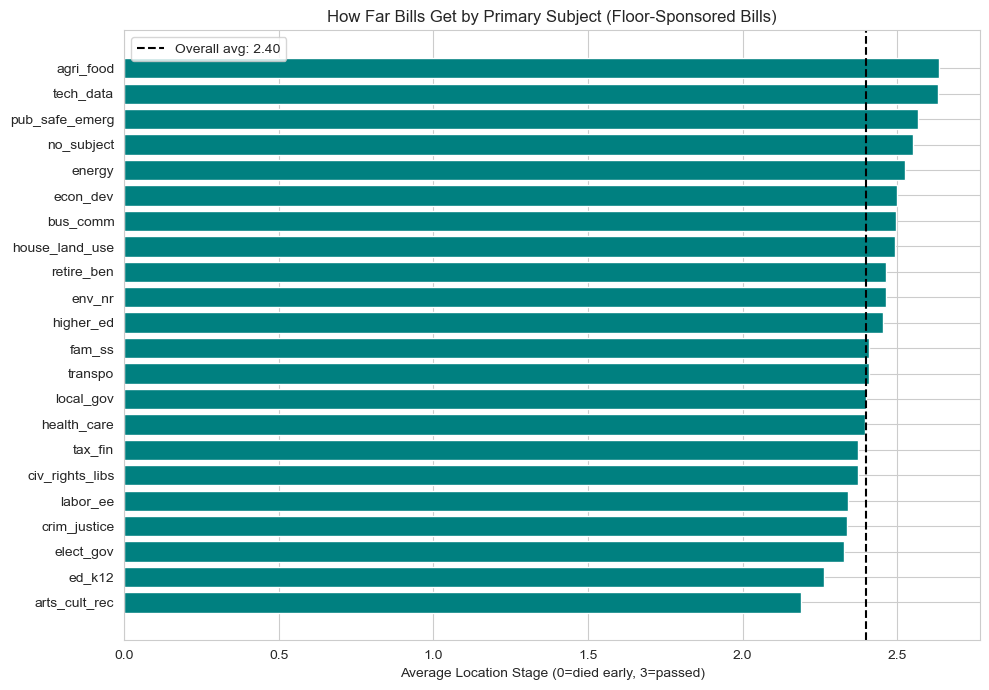

In [18]:
stage_by_subj = {}
for col in SUBJECT_COLS:
    subset = df[df[col] == 1]
    if len(subset) > 10:
        stage_by_subj[col] = subset['location_stage'].mean()

stage_df = pd.Series(stage_by_subj).sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(stage_df.index, stage_df.values, color='teal', edgecolor='white')
ax.axvline(df['location_stage'].mean(), color='black', linestyle='--',
           label=f'Overall avg: {df["location_stage"].mean():.2f}')
ax.set_xlabel('Average Location Stage (0=died early, 3=passed)')
ax.set_title('How Far Bills Get by Primary Subject (Floor-Sponsored Bills)')
ax.legend()
plt.tight_layout()
plt.show()

### 4.1 Location Stage by Party

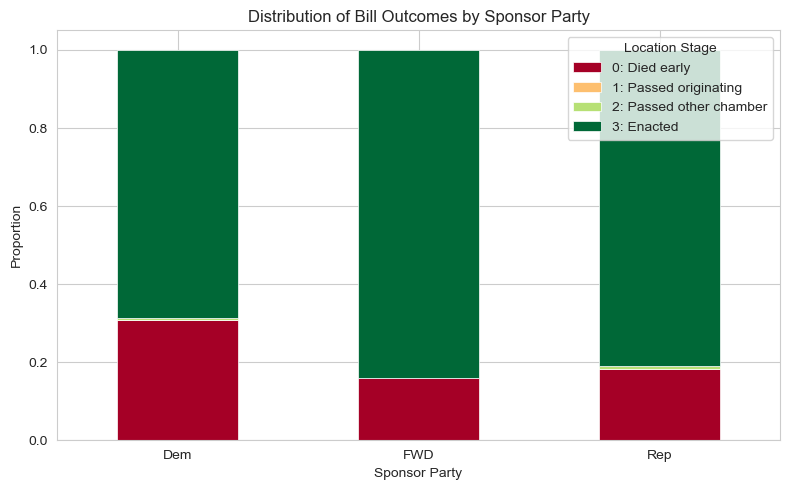

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))
stage_party = df.groupby('party')['location_stage'].value_counts(normalize=True).unstack(fill_value=0)
stage_party.plot(kind='bar', stacked=True, ax=ax, colormap='RdYlGn',
                 edgecolor='white', linewidth=0.5)
ax.set_title('Distribution of Bill Outcomes by Sponsor Party')
ax.set_xlabel('Sponsor Party')
ax.set_ylabel('Proportion')
ax.legend(title='Location Stage', labels=['0: Died early', '1: Passed originating', '2: Passed other chamber', '3: Enacted'])
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

## 5. Summary & Next Steps

### Primary vs Multi-Subject Classification
This notebook uses each bill's **primary** subject only (one dummy per bill) rather than the multi-label encoding. Advantages:
- Cleaner categorical structure — each bill is in exactly one category
- Avoids diluting subject effects when bills span multiple areas
- Makes tree splits more interpretable
- Subject dummies sum to 1 per row, so coefficients reflect true subject effects

Compare the model performance numbers here against the multi-subject notebook to see whether the richer multi-label encoding adds predictive power, or whether primary subjects are sufficient.

### Sample Selection
We restricted to the bills with a floor sponsor that successfully merged with party data. Bills without a floor sponsor cannot pass, so including them would let models trivially predict failure based on procedural filtering rather than substantive bill characteristics.

### Key Findings to Report
- **Best logistic regression model**: shown in section 2 CV table
- **Random forest performance**: CV accuracy, F1, AUC in section 3.1
- **Most important features**: RF feature importance rankings
- **Partisan patterns**: subject × party heatmap (section 1.4) and the `party1` coefficient/importance
- **Policy domain effects**: which primary subjects are most/least likely to pass, and how far they typically get

### Limitations & Future Work
- `party1` is binary (Rep vs. not-Rep); Democrats and Forward Party are grouped together.
- Cosponsor data (`cospon1`, `cospon_num`) is only available from 2023 onward.
- ACS data is missing for 2024–2026.
- The class imbalance is ~80/20 in this filtered sample.
- Consider comparing CV scores against the multi-subject notebook to justify the choice of encoding.